In [1]:
import os
import pickle
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("vizs_4", exist_ok=True)

print("=" * 55)
print("  STEP 4 - ATTENTION MECHANISM")
print("=" * 55)
print(f"  Device : {DEVICE}")

  STEP 4 - ATTENTION MECHANISM
  Device : cpu


In [3]:
class Vocabulary:
    PAD_TOKEN = "<PAD>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"
    UNK_TOKEN = "<UNK>"
    PAD_IDX = 0
    SOS_IDX = 1
    EOS_IDX = 2
    UNK_IDX = 3

    def __init__(self, min_freq=2):
        self.min_freq   = min_freq
        self.word2idx   = {}
        self.idx2word   = {}
        self.word_freq  = Counter()
        self.vocab_size = 0

    @staticmethod
    def tokenize(text):
        if not isinstance(text, str):
            return []
        return text.lower().strip().split()

    def fit(self, sentences):
        for sentence in sentences:
            self.word_freq.update(self.tokenize(sentence))
        return self

    def build(self):
        self.word2idx = {
            self.PAD_TOKEN: self.PAD_IDX,
            self.SOS_TOKEN: self.SOS_IDX,
            self.EOS_TOKEN: self.EOS_IDX,
            self.UNK_TOKEN: self.UNK_IDX,
        }
        for word, freq in self.word_freq.most_common():
            if freq >= self.min_freq and word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)
        self.idx2word   = {idx: word for word, idx in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)
        return self

    def encode(self, sentence, add_sos=False, add_eos=True):
        tokens  = self.tokenize(sentence)
        indices = [self.word2idx.get(t, self.UNK_IDX) for t in tokens]
        if add_sos: indices = [self.SOS_IDX] + indices
        if add_eos: indices = indices + [self.EOS_IDX]
        return indices

    def decode(self, indices, skip_special=True):
        special = {self.PAD_IDX, self.SOS_IDX, self.EOS_IDX}
        words   = []
        for idx in indices:
            if skip_special and idx in special:
                continue
            word = self.idx2word.get(idx, self.UNK_TOKEN)
            words.append(word)
            if word == self.EOS_TOKEN and not skip_special:
                break
        return " ".join(words)

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(self, f)

    @classmethod
    def load(cls, path):
        with open(path, "rb") as f:
            vocab = pickle.load(f)
        print(f"  Vocabulary loaded  ({vocab.vocab_size:,} words)")
        return vocab


# ============================================================
# 2. CONFIG (exact values from Step 2 and Step 3)
# ============================================================

BATCH_SIZE    = 64
MAX_SRC_LEN   = 81
MAX_TGT_LEN   = 12
EMBEDDING_DIM = 128
HIDDEN_DIM    = 256
NUM_LAYERS    = 2
DROPOUT       = 0.5
BIDIRECTIONAL = True

In [5]:
class ReviewSummarizationDataset(Dataset):
    def __init__(self, df, vocab, max_src_len, max_tgt_len):
        self.vocab       = vocab
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
        df               = df.dropna(subset=["body_final", "title_final"]).reset_index(drop=True)
        self.bodies      = df["body_final"].tolist()
        self.titles      = df["title_final"].tolist()

    def __len__(self):
        return len(self.bodies)

    def __getitem__(self, idx):
        src_ids = self.vocab.encode(str(self.bodies[idx]), add_sos=False, add_eos=True)
        src_len = min(len(src_ids), self.max_src_len)
        src_ids = src_ids[:self.max_src_len]
        src_ids = src_ids + [self.vocab.PAD_IDX] * (self.max_src_len - len(src_ids))

        tgt_ids = self.vocab.encode(str(self.titles[idx]), add_sos=True, add_eos=True)
        tgt_len = min(len(tgt_ids), self.max_tgt_len)
        tgt_ids = tgt_ids[:self.max_tgt_len]
        tgt_ids = tgt_ids + [self.vocab.PAD_IDX] * (self.max_tgt_len - len(tgt_ids))

        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long),
            torch.tensor(src_len, dtype=torch.long),
            torch.tensor(tgt_len, dtype=torch.long),
        )


def collate_fn(batch):
    srcs, tgts, src_lens, tgt_lens = zip(*batch)
    srcs     = torch.stack(srcs)
    tgts     = torch.stack(tgts)
    src_lens = torch.stack(src_lens)
    tgt_lens = torch.stack(tgt_lens)
    src_lens, sort_idx = src_lens.sort(descending=True)
    srcs     = srcs[sort_idx]
    tgts     = tgts[sort_idx]
    tgt_lens = tgt_lens[sort_idx]
    return srcs, tgts, src_lens, tgt_lens

In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim,
                 num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)
        self.rnn       = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers    = num_layers,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0,
            batch_first   = True
        )
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src, src_lens):
        embedded   = self.dropout(self.embedding(src))
        packed     = pack_padded_sequence(
            embedded, src_lens.cpu(), batch_first=True, enforce_sorted=True)
        packed_out, hidden = self.rnn(packed)
        outputs, _ = pad_packed_sequence(
            packed_out, batch_first=True, total_length=MAX_SRC_LEN)
        outputs = outputs[:, :, :HIDDEN_DIM] + outputs[:, :, HIDDEN_DIM:]
        hidden  = torch.tanh(self.fc(torch.cat([hidden[-2], hidden[-1]], dim=1)))
        hidden  = hidden.unsqueeze(0).repeat(NUM_LAYERS, 1, 1)
        return outputs, hidden

In [9]:
class Attention(nn.Module):
    """
    Bahdanau additive attention.

    score(s, hi) = v . tanh( W_d.s + W_e.hi )
    alpha        = softmax(scores)
    context      = sum( alpha_i . hi )

    PAD positions masked to -1e10 before softmax so weight is approx 0.

    Inputs:
        decoder_hidden  : (batch, hidden_dim)
        encoder_outputs : (batch, src_len, hidden_dim)
        src_lens        : (batch,)

    Outputs:
        attention_weights : (batch, src_len)
        context_vector    : (batch, hidden_dim)
    """

    def __init__(self, hidden_dim):
        super().__init__()
        self.attn_fc = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v       = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, src_lens=None):
        batch_size, src_len, hidden_dim = encoder_outputs.shape

        # Step 1: broadcast decoder hidden across all src positions
        dec_h = decoder_hidden.unsqueeze(1).expand(-1, src_len, -1)

        # Step 2 and 3: additive energy scores
        combined = torch.cat([dec_h, encoder_outputs], dim=2)
        energy   = self.v(torch.tanh(self.attn_fc(combined))).squeeze(2)

        # Step 4: PAD mask
        if src_lens is not None:
            positions = torch.arange(src_len, device=encoder_outputs.device)
            pad_mask  = positions.unsqueeze(0) >= src_lens.unsqueeze(1)
            energy    = energy.masked_fill(pad_mask, -1e10)

        # Step 5: softmax
        attention_weights = torch.softmax(energy, dim=1)

        # Step 6: weighted sum to get context vector
        context_vector = torch.bmm(
            attention_weights.unsqueeze(1), encoder_outputs
        ).squeeze(1)

        return attention_weights, context_vector

In [11]:
print("\n-- Loading Vocabulary --")
vocab = Vocabulary.load("vocabulary.pkl")


-- Loading Vocabulary --
  Vocabulary loaded  (33,379 words)


In [13]:
print("\n-- Loading CSVs and Building DataLoaders --")

train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")

train_dataset = ReviewSummarizationDataset(train_df, vocab, MAX_SRC_LEN, MAX_TGT_LEN)
val_dataset   = ReviewSummarizationDataset(val_df,   vocab, MAX_SRC_LEN, MAX_TGT_LEN)
test_dataset  = ReviewSummarizationDataset(test_df,  vocab, MAX_SRC_LEN, MAX_TGT_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0,
                          pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0,
                          pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0,
                          pin_memory=torch.cuda.is_available())

print(f"  Train batches : {len(train_loader):,}")
print(f"  Val batches   : {len(val_loader):,}")
print(f"  Test batches  : {len(test_loader):,}")


-- Loading CSVs and Building DataLoaders --
  Train batches : 451
  Val batches   : 51
  Test batches  : 56


In [15]:
print("\n-- Pulling One Fixed Batch --")

src_batch, tgt_batch, src_lens, tgt_lens = next(iter(train_loader))

print(f"  src_batch shape        : {src_batch.shape}")
print(f"  tgt_batch shape        : {tgt_batch.shape}")
print(f"  src_lens (first 8)     : {src_lens[:8].tolist()}")


-- Pulling One Fixed Batch --
  src_batch shape        : torch.Size([64, 81])
  tgt_batch shape        : torch.Size([64, 12])
  src_lens (first 8)     : [81, 80, 76, 72, 70, 61, 61, 61]


In [17]:
print("\n-- Building Encoder and Running Forward Pass --")

encoder = Encoder(
    vocab_size    = vocab.vocab_size,
    embedding_dim = EMBEDDING_DIM,
    hidden_dim    = HIDDEN_DIM,
    num_layers    = NUM_LAYERS,
    dropout       = DROPOUT,
    pad_idx       = vocab.PAD_IDX
)
encoder.eval()

with torch.no_grad():
    enc_outputs, enc_hidden = encoder(src_batch, src_lens)

print(f"  enc_outputs shape : {enc_outputs.shape}   (batch, src_len, hidden_dim)")
print(f"  enc_hidden shape  : {enc_hidden.shape}  (num_layers, batch, hidden_dim)")


-- Building Encoder and Running Forward Pass --
  enc_outputs shape : torch.Size([64, 81, 256])   (batch, src_len, hidden_dim)
  enc_hidden shape  : torch.Size([2, 64, 256])  (num_layers, batch, hidden_dim)


In [19]:
print("\n-- Building Attention and Running Forward Pass --")

attention = Attention(hidden_dim=HIDDEN_DIM)
attention.eval()

print(f"  Attention parameters:")
for name, p in attention.named_parameters():
    print(f"    {name:<25}  shape={list(p.shape)}  count={p.numel():,}")
total_params = sum(p.numel() for p in attention.parameters())
print(f"  Total attention params : {total_params:,}")

with torch.no_grad():
    decoder_hidden_sim        = enc_hidden[-1]
    attn_weights, context_vec = attention(
        decoder_hidden_sim,
        enc_outputs,
        src_lens
    )

print(f"\n  decoder_hidden shape : {decoder_hidden_sim.shape}")
print(f"  attn_weights shape   : {attn_weights.shape}   (probability over 81 positions)")
print(f"  context_vec shape    : {context_vec.shape}   (weighted sum of encoder outputs)")
print(f"  attn_weights range   : [{attn_weights.min():.6f},  {attn_weights.max():.6f}]")
print(f"  context_vec range    : [{context_vec.min():.4f}, {context_vec.max():.4f}]")


-- Building Attention and Running Forward Pass --
  Attention parameters:
    attn_fc.weight             shape=[256, 512]  count=131,072
    attn_fc.bias               shape=[256]  count=256
    v.weight                   shape=[1, 256]  count=256
  Total attention params : 131,584

  decoder_hidden shape : torch.Size([64, 256])
  attn_weights shape   : torch.Size([64, 81])   (probability over 81 positions)
  context_vec shape    : torch.Size([64, 256])   (weighted sum of encoder outputs)
  attn_weights range   : [0.000000,  0.132407]
  context_vec range    : [-0.4823, 0.4610]


In [21]:
print("\n" + "=" * 65)
print("V4-1 | Output Tensor Shape and NaN / Inf Sanity Check")
print("=" * 65)

checks = {
    "attn_weights shape"   : (tuple(attn_weights.shape) == (BATCH_SIZE, MAX_SRC_LEN),
                              str(tuple(attn_weights.shape)),
                              f"expected ({BATCH_SIZE}, {MAX_SRC_LEN})"),
    "context_vec shape"    : (tuple(context_vec.shape) == (BATCH_SIZE, HIDDEN_DIM),
                              str(tuple(context_vec.shape)),
                              f"expected ({BATCH_SIZE}, {HIDDEN_DIM})"),
    "attn_weights no NaN"  : (torch.isnan(attn_weights).sum().item() == 0,
                              f"NaN count: {torch.isnan(attn_weights).sum().item()}",
                              "must be 0"),
    "attn_weights no Inf"  : (torch.isinf(attn_weights).sum().item() == 0,
                              f"Inf count: {torch.isinf(attn_weights).sum().item()}",
                              "must be 0"),
    "context_vec no NaN"   : (torch.isnan(context_vec).sum().item() == 0,
                              f"NaN count: {torch.isnan(context_vec).sum().item()}",
                              "must be 0"),
    "context_vec no Inf"   : (torch.isinf(context_vec).sum().item() == 0,
                              f"Inf count: {torch.isinf(context_vec).sum().item()}",
                              "must be 0"),
    "attn_weights in [0,1]": ((attn_weights.min() >= 0) and (attn_weights.max() <= 1.0001),
                              f"range [{attn_weights.min():.6f}, {attn_weights.max():.6f}]",
                              "must be in [0, 1]"),
    "context_vec finite"   : (torch.isfinite(context_vec).all().item(),
                              f"max abs = {context_vec.abs().max():.4f}",
                              "all finite"),
}

v41_pass = True
for name, (ok, val, exp) in checks.items():
    status = "PASS" if ok else "FAIL"
    if not ok:
        v41_pass = False
    print(f"  {status}  {name:<30}  {val}  ({exp})")

print(f"\n  Result : {'ALL CHECKS PASSED' if v41_pass else 'SOME CHECKS FAILED'}")
print("=" * 65)


V4-1 | Output Tensor Shape and NaN / Inf Sanity Check
  PASS  attn_weights shape              (64, 81)  (expected (64, 81))
  PASS  context_vec shape               (64, 256)  (expected (64, 256))
  PASS  attn_weights no NaN             NaN count: 0  (must be 0)
  PASS  attn_weights no Inf             Inf count: 0  (must be 0)
  PASS  context_vec no NaN              NaN count: 0  (must be 0)
  PASS  context_vec no Inf              Inf count: 0  (must be 0)
  PASS  attn_weights in [0,1]           range [0.000000, 0.132407]  (must be in [0, 1])
  PASS  context_vec finite              max abs = 0.4823  (all finite)

  Result : ALL CHECKS PASSED


In [23]:
print("\n" + "=" * 65)
print("V4-2 | Attention Weights Sum to 1.0")
print("=" * 65)

weight_sums = attn_weights.sum(dim=1)
print("  First 8 samples:")
for i in range(8):
    dev  = abs(weight_sums[i].item() - 1.0)
    flag = "OK" if dev < 1e-5 else "FAIL"
    print(f"    sample {i:2d}: sum={weight_sums[i].item():.8f}  deviation={dev:.2e}  {flag}")

max_dev  = (weight_sums - 1.0).abs().max().item()
v42_pass = torch.allclose(weight_sums, torch.ones_like(weight_sums), atol=1e-5)

print(f"\n  Max deviation from 1.0 across all {BATCH_SIZE} samples : {max_dev:.2e}")
print(f"  Mean sum                                              : {weight_sums.mean().item():.8f}")
print(f"  All sums approx 1.0 (tol=1e-5) : {'PASS' if v42_pass else 'FAIL'}")
print("=" * 65)


V4-2 | Attention Weights Sum to 1.0
  First 8 samples:
    sample  0: sum=0.99999982  deviation=1.79e-07  OK
    sample  1: sum=1.00000000  deviation=0.00e+00  OK
    sample  2: sum=0.99999994  deviation=5.96e-08  OK
    sample  3: sum=1.00000000  deviation=0.00e+00  OK
    sample  4: sum=1.00000012  deviation=1.19e-07  OK
    sample  5: sum=0.99999988  deviation=1.19e-07  OK
    sample  6: sum=1.00000012  deviation=1.19e-07  OK
    sample  7: sum=1.00000012  deviation=1.19e-07  OK

  Max deviation from 1.0 across all 64 samples : 1.79e-07
  Mean sum                                              : 1.00000000
  All sums approx 1.0 (tol=1e-5) : PASS


In [25]:
print("\n" + "=" * 65)
print("V4-3 | PAD Position Masking Verification")
print("=" * 65)

pad_weight_total  = 0.0
pad_slot_count    = 0
nonzero_pad_count = 0
worst_pad_weight  = 0.0

for i in range(BATCH_SIZE):
    tl = src_lens[i].item()
    if tl < MAX_SRC_LEN:
        pad_w = attn_weights[i, tl:].cpu()
        max_w = pad_w.max().item()
        pad_weight_total += pad_w.sum().item()
        pad_slot_count   += pad_w.numel()
        if max_w > 1e-6:
            nonzero_pad_count += 1
        if max_w > worst_pad_weight:
            worst_pad_weight = max_w

samples_with_pad = (src_lens < MAX_SRC_LEN).sum().item()
v43_pass         = (worst_pad_weight < 1e-4) and (nonzero_pad_count == 0)
real_totals      = [attn_weights[i, :src_lens[i].item()].sum().item() for i in range(BATCH_SIZE)]

print(f"  Samples with PAD positions         : {samples_with_pad} / {BATCH_SIZE}")
print(f"  Total PAD slots inspected          : {pad_slot_count:,}")
print(f"  Total attention mass on PAD        : {pad_weight_total:.2e}")
print(f"  Samples with any PAD weight > 1e-6 : {nonzero_pad_count}")
print(f"  Worst single PAD weight seen       : {worst_pad_weight:.2e}")
print(f"\n  PAD masking result : {'PASS' if v43_pass else 'FAIL'}")
print(f"  Mean weight on real positions      : {np.mean(real_totals):.6f}  (should be approx 1.0)")
print("=" * 65)


V4-3 | PAD Position Masking Verification
  Samples with PAD positions         : 63 / 64
  Total PAD slots inspected          : 2,817
  Total attention mass on PAD        : 0.00e+00
  Samples with any PAD weight > 1e-6 : 0
  Worst single PAD weight seen       : 0.00e+00

  PAD masking result : PASS
  Mean weight on real positions      : 1.000000  (should be approx 1.0)



-- V4-4 | Generating Attention Weight Heatmap --


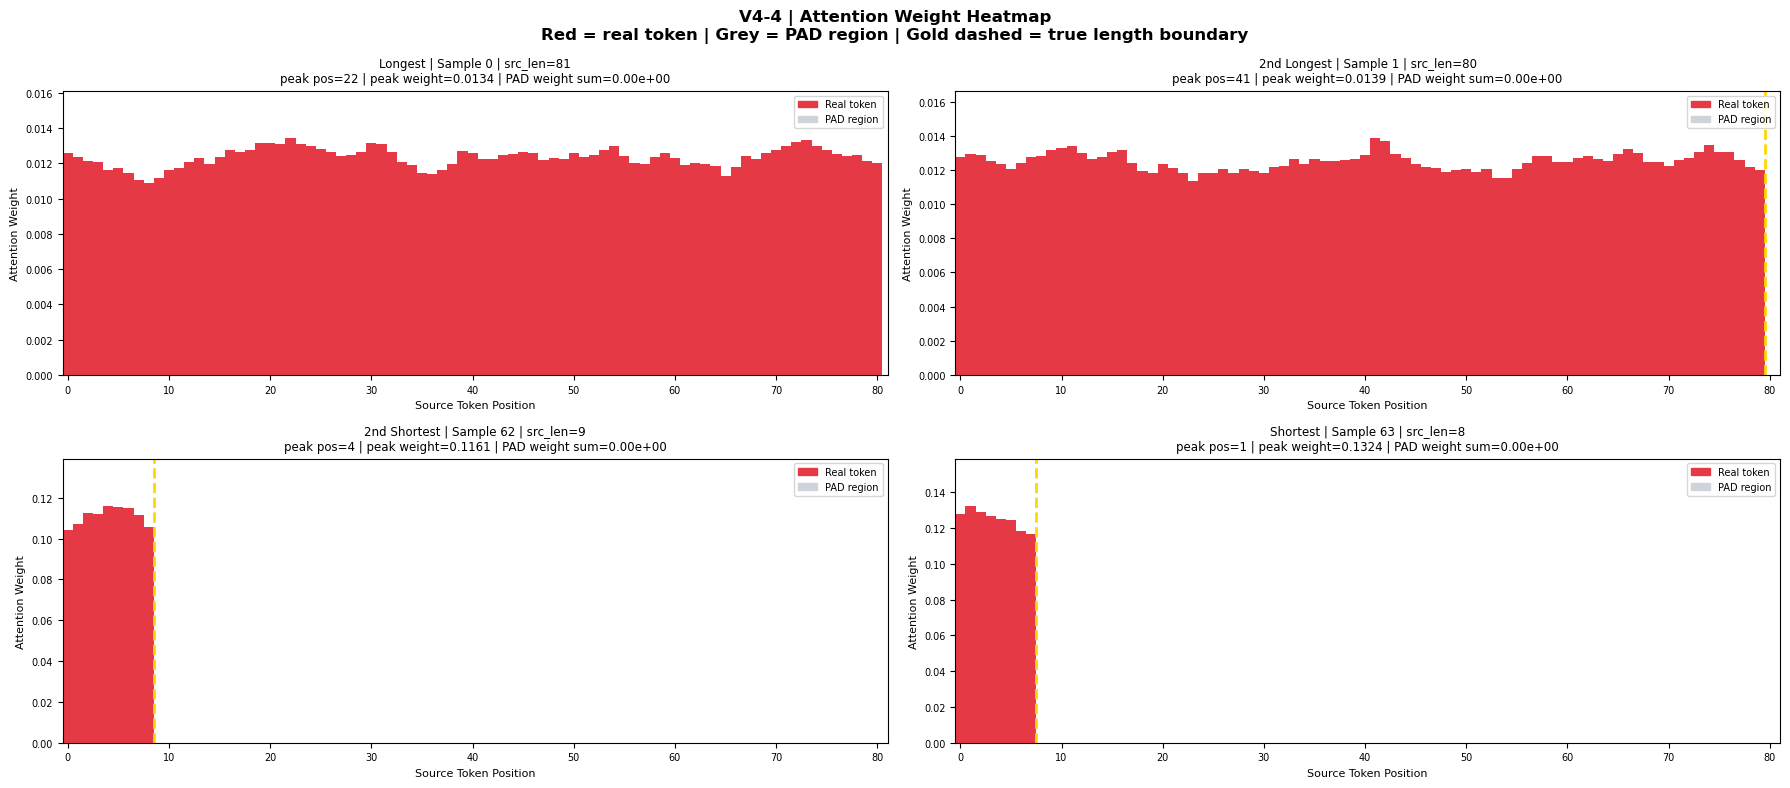

  Saved : vizs_4/V4-4_attention_heatmap.png
  WHAT TO CONFIRM:
  Red bars (real tokens) carry all the weight
  Grey bars (PAD) should be completely flat at 0
  Top 2 plots (longest) show all red, no grey boundary
  Bottom 2 plots (shortest) show grey region on the right clearly at 0


In [27]:
print("\n-- V4-4 | Generating Attention Weight Heatmap --")

fig, axes = plt.subplots(2, 2, figsize=(18, 8))
fig.suptitle(
    "V4-4 | Attention Weight Heatmap\n"
    "Red = real token | Grey = PAD region | Gold dashed = true length boundary",
    fontsize=12, fontweight="bold")

sample_ids = [0, 1, BATCH_SIZE - 2, BATCH_SIZE - 1]
labels     = ["Longest", "2nd Longest", "2nd Shortest", "Shortest"]

with torch.no_grad():
    for plot_idx, (s_idx, label) in enumerate(zip(sample_ids, labels)):
        ax        = axes[plot_idx // 2][plot_idx % 2]
        w         = attn_weights[s_idx].cpu().numpy()
        true_len  = src_lens[s_idx].item()
        positions = np.arange(MAX_SRC_LEN)
        colors    = ["#e63946" if j < true_len else "#ced4da" for j in positions]

        ax.bar(positions, w, color=colors, width=1.0, edgecolor="none")

        if true_len < MAX_SRC_LEN:
            ax.axvline(x=true_len - 0.5, color="gold", linewidth=2.0,
                       linestyle="--", label=f"true_len = {true_len}")

        pad_sum = w[true_len:].sum() if true_len < MAX_SRC_LEN else 0.0
        ax.set_title(
            f"{label} | Sample {s_idx} | src_len={true_len}\n"
            f"peak pos={w[:true_len].argmax()} | "
            f"peak weight={w[:true_len].max():.4f} | "
            f"PAD weight sum={pad_sum:.2e}",
            fontsize=8.5)
        ax.set_xlabel("Source Token Position", fontsize=8)
        ax.set_ylabel("Attention Weight",      fontsize=8)
        ax.set_xlim(-0.5, MAX_SRC_LEN)
        ax.set_ylim(0, max(w[:true_len].max() * 1.2, 0.015))
        ax.tick_params(labelsize=7)

        real_patch = mpatches.Patch(color="#e63946", label="Real token")
        pad_patch  = mpatches.Patch(color="#ced4da", label="PAD region")
        ax.legend(handles=[real_patch, pad_patch], fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("vizs_4/V4-4_attention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved : vizs_4/V4-4_attention_heatmap.png")
print("  WHAT TO CONFIRM:")
print("  Red bars (real tokens) carry all the weight")
print("  Grey bars (PAD) should be completely flat at 0")
print("  Top 2 plots (longest) show all red, no grey boundary")
print("  Bottom 2 plots (shortest) show grey region on the right clearly at 0")


-- V4-5 | Generating Distribution Plots --


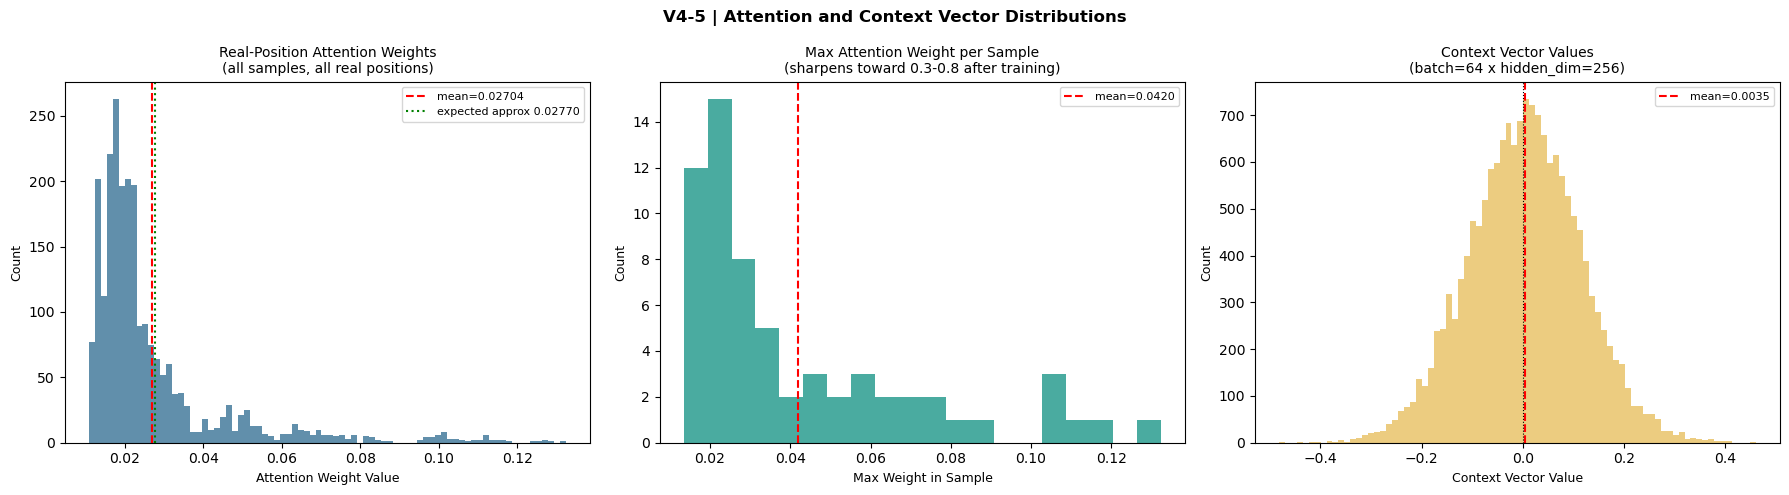

  Saved : vizs_4/V4-5_distributions.png
  Real weights mean : 0.02704  (expected approx 0.02770 for untrained)
  Max per sample    : mean=0.0420
  Context vector    : mean=0.0035  std=0.1112
  NOTE: Untrained attention is nearly uniform. This is correct and expected.


In [29]:
print("\n-- V4-5 | Generating Distribution Plots --")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("V4-5 | Attention and Context Vector Distributions",
             fontsize=12, fontweight="bold")

all_real_w = []
for i in range(BATCH_SIZE):
    tl = src_lens[i].item()
    all_real_w.extend(attn_weights[i, :tl].cpu().numpy().tolist())

axes[0].hist(all_real_w, bins=80, color="#457b9d", edgecolor="none", alpha=0.85)
axes[0].axvline(np.mean(all_real_w), color="red", linestyle="--",
                label=f"mean={np.mean(all_real_w):.5f}")
axes[0].axvline(1.0 / 36.1, color="green", linestyle=":",
                label=f"expected approx {1/36.1:.5f}")
axes[0].set_title("Real-Position Attention Weights\n(all samples, all real positions)", fontsize=10)
axes[0].set_xlabel("Attention Weight Value", fontsize=9)
axes[0].set_ylabel("Count", fontsize=9)
axes[0].legend(fontsize=8)

max_w_per = [attn_weights[i, :src_lens[i].item()].max().item() for i in range(BATCH_SIZE)]
axes[1].hist(max_w_per, bins=20, color="#2a9d8f", edgecolor="none", alpha=0.85)
axes[1].axvline(np.mean(max_w_per), color="red", linestyle="--",
                label=f"mean={np.mean(max_w_per):.4f}")
axes[1].set_title("Max Attention Weight per Sample\n"
                  "(sharpens toward 0.3-0.8 after training)", fontsize=10)
axes[1].set_xlabel("Max Weight in Sample", fontsize=9)
axes[1].set_ylabel("Count", fontsize=9)
axes[1].legend(fontsize=8)

ctx_flat = context_vec.detach().cpu().numpy().flatten()
axes[2].hist(ctx_flat, bins=80, color="#e9c46a", edgecolor="none", alpha=0.85)
axes[2].axvline(ctx_flat.mean(), color="red", linestyle="--",
                label=f"mean={ctx_flat.mean():.4f}")
axes[2].axvline(0, color="black", linestyle=":", linewidth=0.8)
axes[2].set_title(f"Context Vector Values\n"
                  f"(batch={BATCH_SIZE} x hidden_dim={HIDDEN_DIM})", fontsize=10)
axes[2].set_xlabel("Context Vector Value", fontsize=9)
axes[2].set_ylabel("Count", fontsize=9)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("vizs_4/V4-5_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved : vizs_4/V4-5_distributions.png")
print(f"  Real weights mean : {np.mean(all_real_w):.5f}  (expected approx {1/36.1:.5f} for untrained)")
print(f"  Max per sample    : mean={np.mean(max_w_per):.4f}")
print(f"  Context vector    : mean={ctx_flat.mean():.4f}  std={ctx_flat.std():.4f}")
print("  NOTE: Untrained attention is nearly uniform. This is correct and expected.")

In [31]:
print("\n" + "=" * 65)
print("V4-6 | Gradient Flow Check")
print("=" * 65)

attention.train()
encoder.train()

opt_test = torch.optim.Adam(
    list(encoder.parameters()) + list(attention.parameters()), lr=1e-3)
opt_test.zero_grad()

enc_out_g, enc_hid_g = encoder(src_batch, src_lens)
dec_h_g              = enc_hid_g[-1]
attn_w_g, ctx_g      = attention(dec_h_g, enc_out_g, src_lens)

loss = ctx_g.sum() + attn_w_g.sum()
loss.backward()

print(f"  {'Layer':<28} {'Grad Mean':>12} {'Grad Std':>12} {'Status':>12}")
print(f"  {'-'*28} {'-'*12} {'-'*12} {'-'*12}")

v46_pass = True
for name, param in attention.named_parameters():
    if param.grad is not None:
        gm = param.grad.abs().mean().item()
        gs = param.grad.std().item()
        if gm == 0.0:
            status = "DEAD";    v46_pass = False
        elif gm > 10.0:
            status = "EXPLODE"; v46_pass = False
        else:
            status = "OK"
        print(f"  {name:<28} {gm:>12.6f} {gs:>12.6f} {status:>12}")
    else:
        print(f"  {name:<28} {'NO GRAD':>12} {'':>12} {'FAIL':>12}")
        v46_pass = False

print(f"\n  Result : {'ALL GRADIENTS HEALTHY' if v46_pass else 'ISSUES FOUND'}")
print("=" * 65)

attention.eval()
encoder.eval()


V4-6 | Gradient Flow Check
  Layer                           Grad Mean     Grad Std       Status
  ---------------------------- ------------ ------------ ------------
  attn_fc.weight                   0.072665     0.144867           OK
  attn_fc.bias                     0.004937     0.007424           OK
  v.weight                         2.016065     2.528766           OK

  Result : ALL GRADIENTS HEALTHY


Encoder(
  (embedding): Embedding(33379, 128, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (rnn): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=256, bias=True)
)

In [33]:
print("\n" + "=" * 65)
print("V4-7 | Determinism Check (eval mode)")
print("=" * 65)

with torch.no_grad():
    eo1, eh1 = encoder(src_batch, src_lens)
    w1, c1   = attention(eh1[-1], eo1, src_lens)

    eo2, eh2 = encoder(src_batch, src_lens)
    w2, c2   = attention(eh2[-1], eo2, src_lens)

w_diff   = (w1 - w2).abs().max().item()
c_diff   = (c1 - c2).abs().max().item()
v47_pass = (w_diff == 0.0) and (c_diff == 0.0)

print(f"  Run 1 vs Run 2 — max difference in attention_weights : {w_diff:.2e}")
print(f"  Run 1 vs Run 2 — max difference in context_vector   : {c_diff:.2e}")
print(f"\n  Result : {'DETERMINISTIC' if v47_pass else 'NON-DETERMINISTIC'}")
print("=" * 65)


V4-7 | Determinism Check (eval mode)
  Run 1 vs Run 2 — max difference in attention_weights : 0.00e+00
  Run 1 vs Run 2 — max difference in context_vector   : 0.00e+00

  Result : DETERMINISTIC


In [35]:
print("\n" + "=" * 65)
print("V4-8 | Masking Stress Test (edge case lengths)")
print("=" * 65)

cases = [
    ("length=1  (single token)",   torch.tensor([1])),
    ("length=5  (very short)",     torch.tensor([5])),
    ("length=40 (medium)",         torch.tensor([40])),
    ("length=81 (maximum full)",   torch.tensor([81])),
]

v48_pass = True
with torch.no_grad():
    for desc, stress_lens in cases:
        fe  = torch.randn(1, MAX_SRC_LEN, HIDDEN_DIM)
        fdh = torch.randn(1, HIDDEN_DIM)
        w, ctx = attention(fdh, fe, stress_lens)

        tl       = stress_lens.item()
        real_sum = w[0, :tl].sum().item()
        pad_sum  = w[0, tl:].sum().item() if tl < MAX_SRC_LEN else 0.0
        total    = w[0].sum().item()
        ok       = abs(total - 1.0) < 1e-5 and abs(pad_sum) < 1e-5
        if not ok:
            v48_pass = False

        status = "PASS" if ok else "FAIL"
        print(f"  {status}  {desc}")
        print(f"         real_sum={real_sum:.6f}  pad_sum={pad_sum:.2e}  "
              f"total={total:.6f}  ctx_norm={ctx.norm().item():.4f}")

print(f"\n  Stress test : {'ALL PASSED' if v48_pass else 'FAILURES DETECTED'}")
print("=" * 65)


V4-8 | Masking Stress Test (edge case lengths)
  PASS  length=1  (single token)
         real_sum=1.000000  pad_sum=0.00e+00  total=1.000000  ctx_norm=16.9560
  PASS  length=5  (very short)
         real_sum=1.000000  pad_sum=0.00e+00  total=1.000000  ctx_norm=6.7409
  PASS  length=40 (medium)
         real_sum=1.000000  pad_sum=0.00e+00  total=1.000000  ctx_norm=2.6545
  PASS  length=81 (maximum full)
         real_sum=1.000000  pad_sum=0.00e+00  total=1.000000  ctx_norm=1.7343

  Stress test : ALL PASSED



-- V4-9 | Multi-Step Simulation --


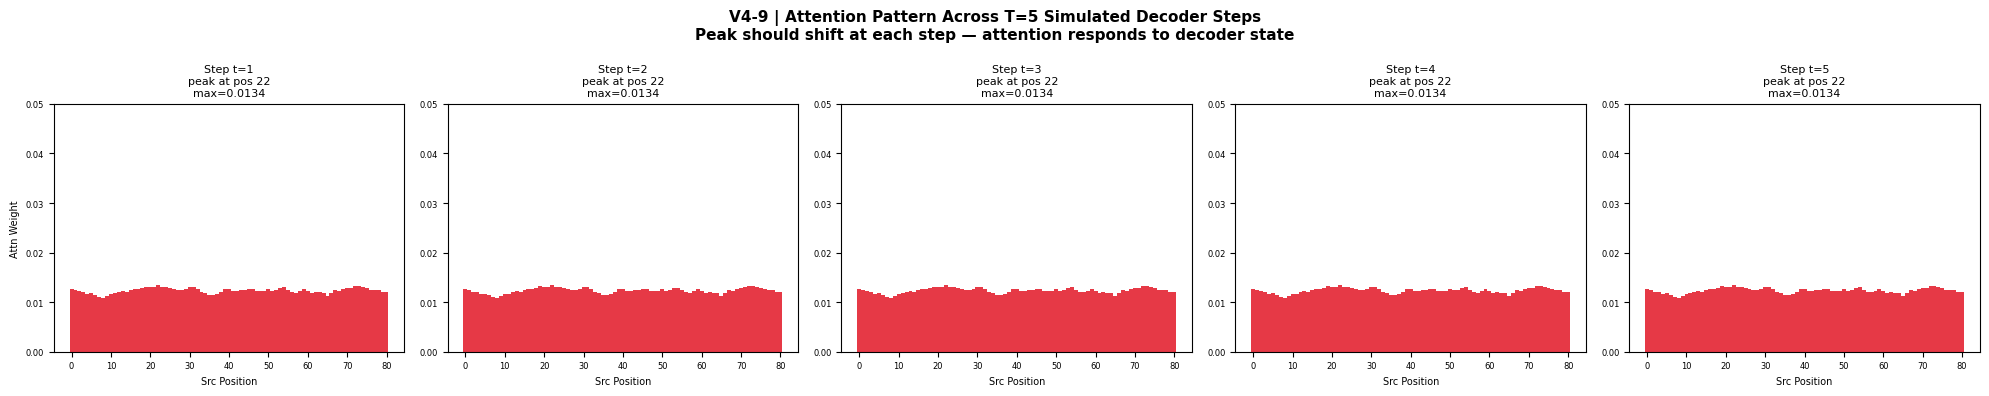

  Saved : vizs_4/V4-9_multistep_simulation.png
  WHAT TO CONFIRM:
  Peak position shifts across the 5 steps
  Grey PAD region remains flat at 0 throughout all steps


In [37]:
print("\n-- V4-9 | Multi-Step Simulation --")

T = 5
fig, axes = plt.subplots(1, T, figsize=(20, 4))
fig.suptitle(
    "V4-9 | Attention Pattern Across T=5 Simulated Decoder Steps\n"
    "Peak should shift at each step — attention responds to decoder state",
    fontsize=11, fontweight="bold")

SAMPLE_IDX = 0
with torch.no_grad():
    single_enc = enc_outputs[SAMPLE_IDX].unsqueeze(0)
    single_len = src_lens[SAMPLE_IDX].unsqueeze(0)
    torch.manual_seed(99)

    for t in range(T):
        dec_h  = torch.randn(1, HIDDEN_DIM) * 0.3
        w, ctx = attention(dec_h, single_enc, single_len)
        w_np   = w[0].cpu().numpy()
        tl     = single_len.item()
        colors = ["#e63946" if j < tl else "#dee2e6" for j in range(MAX_SRC_LEN)]

        axes[t].bar(np.arange(MAX_SRC_LEN), w_np, color=colors, width=1.0, edgecolor="none")
        if tl < MAX_SRC_LEN:
            axes[t].axvline(x=tl - 0.5, color="gold", linewidth=1.5,
                            linestyle="--", alpha=0.8)
        axes[t].set_title(f"Step t={t+1}\npeak at pos {w_np[:tl].argmax()}\n"
                          f"max={w_np[:tl].max():.4f}", fontsize=8)
        axes[t].set_ylim(0, max(w_np[:tl].max() * 1.25, 0.05))
        axes[t].set_xlabel("Src Position", fontsize=7)
        if t == 0:
            axes[t].set_ylabel("Attn Weight", fontsize=7)
        axes[t].tick_params(labelsize=6)

plt.tight_layout()
plt.savefig("vizs_4/V4-9_multistep_simulation.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved : vizs_4/V4-9_multistep_simulation.png")
print("  WHAT TO CONFIRM:")
print("  Peak position shifts across the 5 steps")
print("  Grey PAD region remains flat at 0 throughout all steps")